# TCR–Epitope Binding Prediction: Full Analysis

This notebook covers the complete analysis pipeline in three parts:

1. **Embedding structure** — TCR and epitope ESM2 embeddings analysed separately (UMAP, clustering)
2. **Joint embedding + model results** — TCR+Epitope concatenated, RF vs LR comparison
3. **Biological interpretation** — metadata coloring, GNN motivation

**Data loaded from:** `outputs/shap_data.pkl` (produced by `tcr_epitope_minimal.py`)  
**MLflow metrics loaded from:** `outputs/mlflow.db`

## Setup

In [ ]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import umap
import mlflow
import mlflow.sklearn
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "legend.fontsize": 8,
})

# ── paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR = Path(os.path.expanduser("~/projectsZHAW/VT1/iggytop"))
OUTPUTS_DIR = PROJECT_DIR / "outputs" / "outputs_v5"   # ← update version here
SHAP_PKL    = OUTPUTS_DIR / "shap_data.pkl"
RF_PKL      = OUTPUTS_DIR / "random_forest.pkl"
LR_PKL      = OUTPUTS_DIR / "logistic_regression.pkl"
MLFLOW_URI  = f"sqlite:///{OUTPUTS_DIR}/mlflow.db"
FIG_DIR     = PROJECT_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_VIZ       = 3000
EMB_DIM     = 320
TOP_N_EPI   = 10

print("Setup complete")
print(f"SHAP pkl exists : {SHAP_PKL.exists()}")
print(f"RF pkl exists   : {RF_PKL.exists()}")
print(f"MLflow db exists: {(OUTPUTS_DIR / 'mlflow.db').exists()}")

## Load Data

The pickle file contains everything saved by the training script:
- `X_test_tcr` / `X_test_epi` — split embeddings for Parts 1 and 2
- `X_test` — concatenated (640-dim), what the RF was trained on
- `df_test_meta` — metadata per test sample (epitope, species, source, MHC class)
- `run_id` — used in Part 2 to pull metrics from MLflow

In [ ]:
with open(SHAP_PKL, "rb") as f:
    sd = pickle.load(f)

# embeddings
X_test     = sd["X_test"]          # (N, 640) — concatenated, for RF
tcr_emb    = sd["X_test_tcr"]      # (N, 320) — TCR only
epi_emb    = sd["X_test_epi"]      # (N, 320) — epitope only
y_test     = sd["y_test"]
rf_probs   = sd["rf_probs"]
lr_probs   = sd.get("lr_probs", None)

# metadata
meta       = sd.get("df_test_meta", pd.DataFrame())
run_id     = sd["run_id"]

print(f"X_test shape     : {X_test.shape}")
print(f"TCR emb shape    : {tcr_emb.shape}")
print(f"Epitope emb shape: {epi_emb.shape}")
print(f"y_test shape     : {y_test.shape}")
print(f"Metadata columns : {list(meta.columns)}")
print(f"\nMetadata preview:")
meta.head(3)

In [ ]:
rng      = np.random.default_rng(RANDOM_SEED)
idx      = rng.choice(len(y_test), min(N_VIZ, len(y_test)), replace=False)

tcr_sub  = tcr_emb[idx]
epi_sub  = epi_emb[idx]
y_sub    = y_test[idx]
meta_sub = meta.iloc[idx].reset_index(drop=True) if len(meta) > 0 else pd.DataFrame()

binding_labels = np.where(y_sub == 1, "binding", "non-binding")
epi_labels     = meta_sub["epitope"].values         if "epitope"         in meta_sub.columns else np.array(["unknown"]*len(idx))
species_labels = meta_sub["antigen_species"].values if "antigen_species"  in meta_sub.columns else np.array(["unknown"]*len(idx))

print(f"Subsample        : {len(idx)}")
print(f"Unique epitopes  : {pd.Series(epi_labels).nunique()}")
print(f"Unique species   : {pd.Series(species_labels).nunique()}")
print(f"Species counts:\n{pd.Series(species_labels).value_counts().head(8)}")

---
## Part 1: TCR and Epitope Embeddings Separately

We first look at each modality in isolation to understand what structure ESM2 captures before combining them for the model.

In [ ]:
def run_umap(emb, label):
    print(f"Running UMAP on {label} embeddings {emb.shape} ...")
    reducer = umap.UMAP(n_components=2, n_neighbors=30,
                         min_dist=0.1, random_state=RANDOM_SEED, n_jobs=1)
    coords = reducer.fit_transform(emb)
    print(f"  Done.")
    return coords

tcr_2d = run_umap(tcr_sub, "TCR")
epi_2d = run_umap(epi_sub, "Epitope")

### TCR embeddings — colored by binding label

If binding and non-binding TCRs **mix completely**, it means the TCR sequence alone does not determine binding. The epitope must be considered too — which is biologically correct.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
palette = {"binding": "#534AB7", "non-binding": "#BA7517"}

for label, color in palette.items():
    mask = binding_labels == label
    ax.scatter(tcr_2d[mask, 0], tcr_2d[mask, 1],
               c=color, label=label, s=10, alpha=0.5, linewidths=0, rasterized=True)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("TCR embeddings — colored by binding label")
ax.legend(title="Label", frameon=False, markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "tcr_umap_binding.png", bbox_inches="tight")
plt.show()

KeyboardInterrupt: 

### TCR embeddings — top 10 most frequent epitopes highlighted

**Key diagnostic plot.** If TCRs that bind the same epitope cluster together, the ESM2 embedding space captures specificity at the sequence level — a strong signal for GNNs. If they scatter randomly, specificity lives in higher-dimensional structure not visible in 2D.

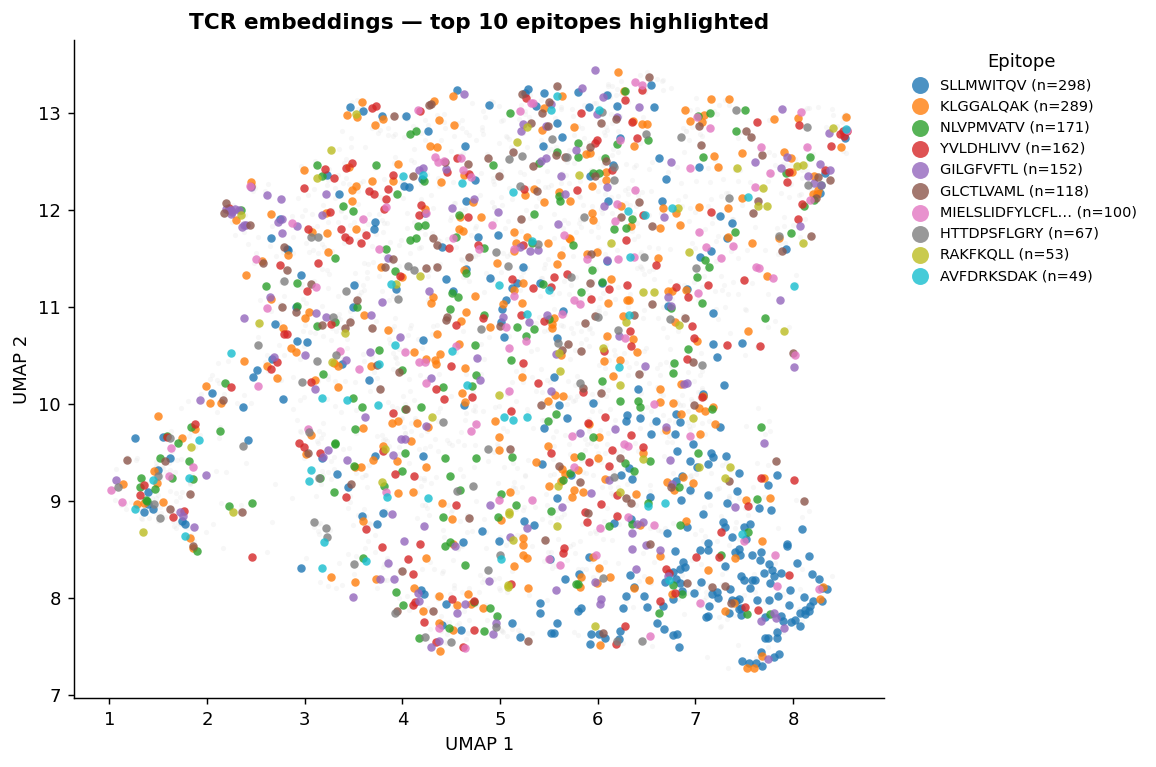

In [ ]:
counts   = pd.Series(epi_labels).value_counts()
top_epis = counts.head(TOP_N_EPI).index.tolist()
palette  = sns.color_palette("tab10", TOP_N_EPI).as_hex()

# gray background — all TCRs
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(tcr_2d[:, 0], tcr_2d[:, 1],
           c="#e0e0e0", s=8, alpha=0.25, linewidths=0, rasterized=True, label="_nolegend_")

for i, epi in enumerate(top_epis):
    mask  = epi_labels == epi
    short = epi[:14] + "…" if len(epi) > 14 else epi
    ax.scatter(tcr_2d[mask, 0], tcr_2d[mask, 1],
               c=[palette[i]], s=22, alpha=0.8, linewidths=0,
               label=f"{short} (n={mask.sum()})", rasterized=True)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(f"TCR embeddings — top {TOP_N_EPI} epitopes highlighted")
ax.legend(title="Epitope", bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, markerscale=2, handletextpad=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "tcr_umap_top_epitopes.png", bbox_inches="tight")
plt.show()

### Epitope embeddings — colored by binding label

The same epitope appears in both positive and negative pairs (positive: its known TCR; negative: a random TCR). Mixing here is expected and confirms the labels are correctly constructed.

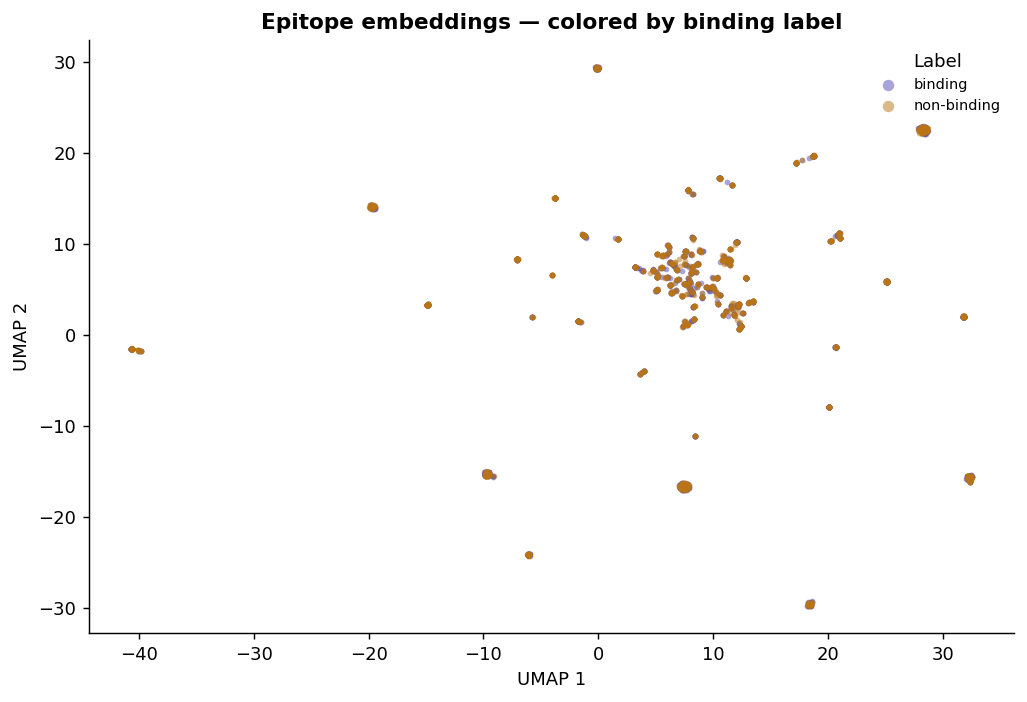

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
palette = {"binding": "#534AB7", "non-binding": "#BA7517"}

for label, color in palette.items():
    mask = binding_labels == label
    ax.scatter(epi_2d[mask, 0], epi_2d[mask, 1],
               c=color, label=label, s=10, alpha=0.5, linewidths=0, rasterized=True)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Epitope embeddings — colored by binding label")
ax.legend(title="Label", frameon=False, markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "epi_umap_binding.png", bbox_inches="tight")
plt.show()

### Epitope embeddings — colored by pathogen species

If ESM2 groups epitopes from the same pathogen together, it means the model has learned biochemical similarity between peptides from the same organism — expected, since viral proteins share sequence motifs.

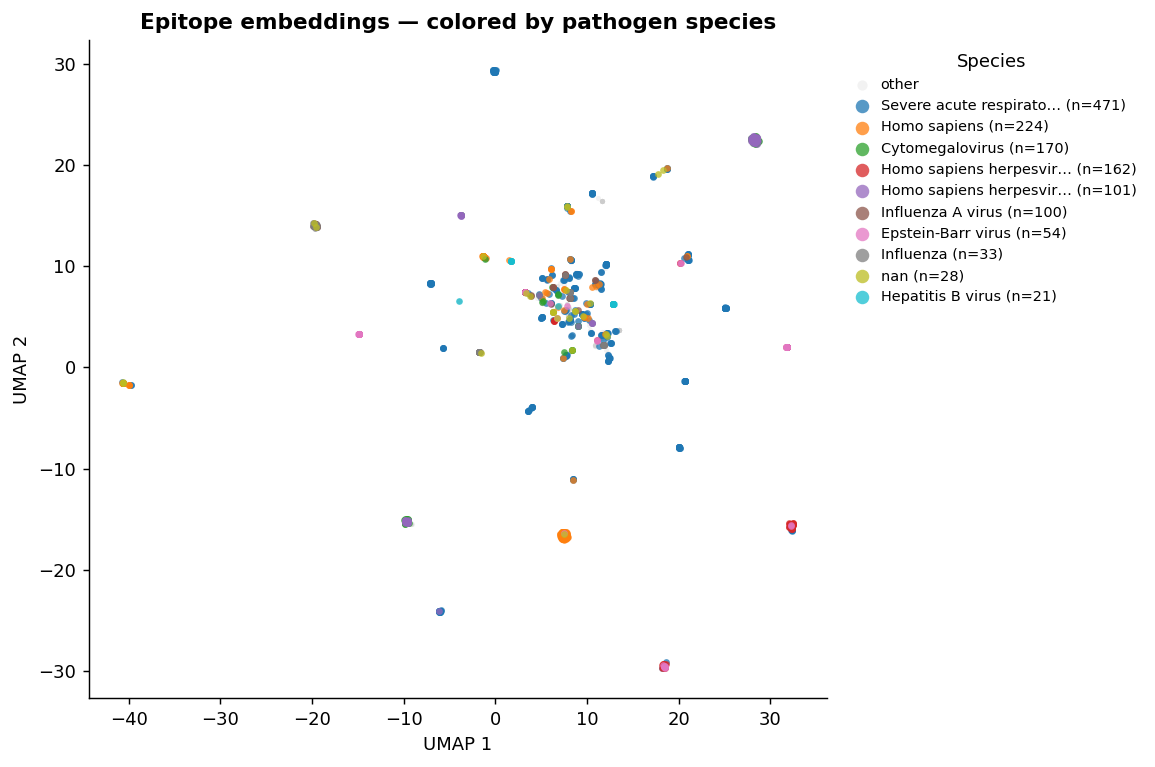

In [ ]:
top_sp  = pd.Series(species_labels).value_counts().head(10).index.tolist()
palette = sns.color_palette("tab10", 10).as_hex()
disp_sp = np.where(pd.Series(species_labels).isin(top_sp), species_labels, "other")

fig, ax = plt.subplots(figsize=(9, 6))
sp_pal  = {s: palette[i] for i, s in enumerate(top_sp)}
sp_pal["other"] = "#cccccc"

# draw "other" first so it sits at the back
mask_other = disp_sp == "other"
ax.scatter(epi_2d[mask_other, 0], epi_2d[mask_other, 1],
           c="#cccccc", s=8, alpha=0.25, linewidths=0, rasterized=True, label="other")

for sp in top_sp:
    mask = disp_sp == sp
    short = sp[:22] + "…" if len(sp) > 22 else sp
    ax.scatter(epi_2d[mask, 0], epi_2d[mask, 1],
               c=sp_pal[sp], s=14, alpha=0.75, linewidths=0,
               label=f"{short} (n={mask.sum()})", rasterized=True)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Epitope embeddings — colored by pathogen species")
ax.legend(title="Species", bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, markerscale=2, handletextpad=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "epi_umap_species.png", bbox_inches="tight")
plt.show()

### Clustering metrics

Two complementary metrics quantify what we see visually:

- **Silhouette score** (−1 to +1): measures how well each point fits its own group vs. neighbouring groups. Score > 0.1 indicates detectable structure.
- **Intra/inter epitope distance ratio**: ratio < 1 means TCRs binding the same epitope are more similar to each other than to random TCRs — i.e. clustering exists.

In [ ]:
def clustering_metrics(emb, labels, label_name, min_count=10):
    counts = pd.Series(labels).value_counts()
    valid  = counts[counts >= min_count].index
    mask   = pd.Series(labels).isin(valid).values

    print(f"\n{label_name}")
    print(f"  Valid groups (n≥{min_count}): {len(valid)}, samples: {mask.sum()}")

    if mask.sum() < 50:
        print("  Not enough samples.")
        return {}

    sub_emb = emb[mask]
    sub_lbl = np.array(labels)[mask]

    # ── guard: need at least 2 unique labels for silhouette ──────────────
    n_unique = len(np.unique(sub_lbl))
    if n_unique < 2:
        print(f"  Only {n_unique} unique label(s) after filtering — skipping silhouette.")
        print("  Tip: increase N_VIZ or lower min_count to get more diversity.")
        return {"silhouette_score": float("nan"), "note": "only 1 label in subsample"}

    # silhouette
    n_sil = min(2000, len(sub_emb))
    rng2  = np.random.default_rng(RANDOM_SEED)
    s_idx = rng2.choice(len(sub_emb), n_sil, replace=False)
    sil   = silhouette_score(sub_emb[s_idx], sub_lbl[s_idx], metric="cosine")

    # intra vs inter
    unique = valid[:10]
    intra_list, inter_list = [], []
    for grp in unique:
        grp_mask = sub_lbl == grp
        oth_mask = sub_lbl != grp
        vecs     = sub_emb[grp_mask]
        if len(vecs) < 2 or oth_mask.sum() < 1:
            continue
        d = cosine_distances(vecs)
        intra_list.append(d[np.triu_indices_from(d, k=1)].mean())
        other_vecs = sub_emb[oth_mask]
        o_idx = rng2.choice(len(other_vecs), min(200, len(other_vecs)), replace=False)
        inter_list.append(cdist(vecs[:5], other_vecs[o_idx], metric="cosine").mean())

    if not intra_list:
        print("  No valid groups for distance comparison.")
        return {"silhouette_score": round(sil, 4)}

    results = {
        "silhouette_score"    : round(sil, 4),
        "mean_intra_dist"     : round(np.mean(intra_list), 4),
        "mean_inter_dist"     : round(np.mean(inter_list), 4),
        "intra_inter_ratio"   : round(np.mean(intra_list) / np.mean(inter_list), 4),
    }
    for k, v in results.items():
        print(f"  {k:<25}: {v}")
    return results

tcr_metrics = clustering_metrics(tcr_sub, epi_labels,     "TCR embeddings — by epitope")
epi_metrics = clustering_metrics(epi_sub, species_labels, "Epitope embeddings — by species")


TCR embeddings — by epitope
  Valid groups (n≥10): 47, samples: 2142
  silhouette_score         : -0.23890000581741333
  mean_intra_dist          : 0.028200000524520874
  mean_inter_dist          : 0.0293
  intra_inter_ratio        : 0.9644

Epitope embeddings — by species
  Valid groups (n≥10): 15, samples: 1429
  silhouette_score         : -0.19249999523162842
  mean_intra_dist          : 0.046300001442432404
  mean_inter_dist          : 0.0639
  intra_inter_ratio        : 0.7244


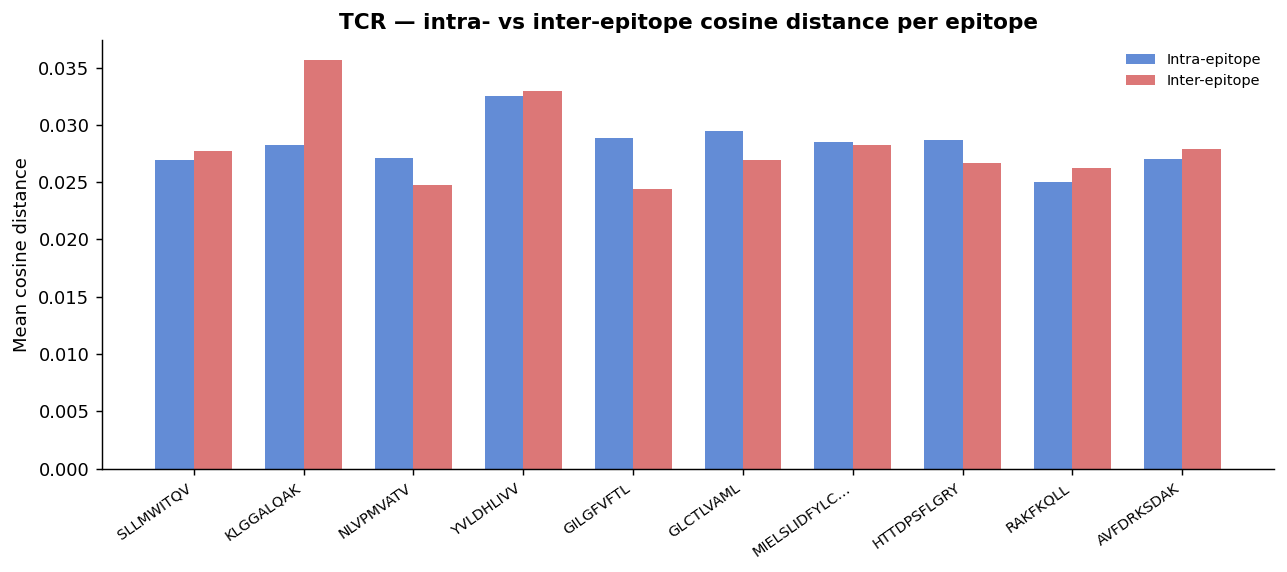

In [ ]:
counts   = pd.Series(epi_labels).value_counts()
top_epis = counts.head(TOP_N_EPI).index.tolist()
rng3     = np.random.default_rng(RANDOM_SEED)
rows     = []

for epi in top_epis:
    mask  = epi_labels == epi
    other = epi_labels != epi
    vecs  = tcr_sub[mask]
    if len(vecs) < 2:
        continue
    d_intra = cosine_distances(vecs)
    intra   = d_intra[np.triu_indices_from(d_intra, k=1)].mean()
    other_v = tcr_sub[other]
    o_idx   = rng3.choice(len(other_v), min(300, len(other_v)), replace=False)
    inter   = cdist(vecs[:10], other_v[o_idx], metric="cosine").mean()
    short   = epi[:12] + "…" if len(epi) > 12 else epi
    rows.append({"epitope": short, "intra": intra, "inter": inter})

df_d = pd.DataFrame(rows)
x, w = np.arange(len(df_d)), 0.35

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, df_d["intra"], w, label="Intra-epitope", color="#4878CF", alpha=0.85)
ax.bar(x + w/2, df_d["inter"], w, label="Inter-epitope", color="#D65F5F", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_d["epitope"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Mean cosine distance")
ax.set_title("TCR — intra- vs inter-epitope cosine distance per epitope")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "tcr_distance_comparison.png", bbox_inches="tight")
plt.show()

---
## Part 2: Joint Embedding and Model Performance

We now load the trained models and MLflow metrics to evaluate how well the concatenated TCR+Epitope embedding predicts binding.

In [ ]:
# load models from local pickle (portable — no dependency on cluster artifact paths)
with open(RF_PKL, "rb") as f:
    rf = pickle.load(f)
with open(LR_PKL, "rb") as f:
    lr = pickle.load(f)

# load metrics from MLflow using the run_id saved in shap_data.pkl
mlflow.set_tracking_uri(MLFLOW_URI)
run     = mlflow.get_run(run_id)
metrics = run.data.metrics
params  = run.data.params

print(f"Run: {run.info.run_name}  |  Status: {run.info.status}")
print(f"\nParams: {params}")

### Model comparison

**AUC-ROC** is the primary metric. Random Forest substantially outperforms Logistic Regression, confirming the binding signal is non-linear in ESM2 embedding space.

In [ ]:
metric_names = ['auc', 'aupr', 'f1', 'precision', 'recall', 'specificity', 'accuracy', 'optimal_f1']

comparison_data = {'Logistic Regression': {}, 'Random Forest': {}}
for m in metric_names:
    if f'logistic_regression_{m}' in metrics:
        comparison_data['Logistic Regression'][m] = metrics[f'logistic_regression_{m}']
    if f'random_forest_{m}' in metrics:
        comparison_data['Random Forest'][m] = metrics[f'random_forest_{m}']

comparison = pd.DataFrame(comparison_data)

print('=' * 60)
print('MODEL COMPARISON')
print('=' * 60)
print(comparison.round(4).to_string())
print('=' * 60)

auc_lr = comparison.loc['auc', 'Logistic Regression']
auc_rf = comparison.loc['auc', 'Random Forest']
winner = 'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'
print(f'\nWinner by AUC: {winner} (margin: {abs(auc_rf - auc_lr):.4f})')

The ROC and PR curves below show the full trade-off curves. The heatmap summarises all metrics at a glance.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for probs, label, color in [
    (rf_probs, f'Random Forest (AUC={auc_rf:.3f})', '#1f77b4'),
    (lr_probs, f'Logistic Regression (AUC={auc_lr:.3f})', '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=label, color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# PR curves
aupr_rf = metrics.get('random_forest_aupr', 0)
aupr_lr = metrics.get('logistic_regression_aupr', 0)
for probs, label, color in [
    (rf_probs, f'Random Forest (AUPR={aupr_rf:.3f})', '#1f77b4'),
    (lr_probs, f'Logistic Regression (AUPR={aupr_lr:.3f})', '#d62728'),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=label, color=color, lw=2)
axes[1].axhline(y=0.5, color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Heatmap
heatmap_data = comparison.drop('optimal_f1', errors='ignore')
sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=axes[2], cbar_kws={'label': 'Score'})
axes[2].set_title('Metrics Heatmap', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(OUTPUTS_DIR, 'metrics_visualization.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

### Joint embedding UMAP (TCR + Epitope = 640 dims)

This is the space the Random Forest actually operates in. Unlike the TCR-only UMAP (Part 1), distinct islands emerge here — each corresponding to a group of TCR–epitope pairs that are jointly similar. Several islands are almost entirely one binding class.

In [ ]:
# ── UMAP on the full concatenated embedding (TCR + epitope = 640 dims) ────
# This is what the Random Forest actually learned from
# %pip install umap-learn plotly

import umap
import plotly.express as px
import pandas as pd
import numpy as np

# ── 1. Subsample for speed (UMAP on 120k points is slow in a notebook) ────
N_VIZ = 3000
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_test), size=N_VIZ, replace=False)

X_viz = X_test[idx]          # (3000, 640)  — ESM2 embeddings
y_viz = y_test[idx]           # 0 = non-binding, 1 = binding

print("Running UMAP on TCR + epitope embeddings (640 dims)...")
reducer_full = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                          random_state=42, n_jobs=1)
full_2d = reducer_full.fit_transform(X_viz)   # (3000, 640) → (3000, 2)

df_full = pd.DataFrame({
    "UMAP 1"  : full_2d[:, 0],
    "UMAP 2"  : full_2d[:, 1],
    "label"   : ["binding" if l == 1 else "non-binding" for l in y_viz],
    "prob_rf" : rf.predict_proba(X_viz)[:, 1].round(3),
    "symbol"  : ["circle" if l == 1 else "square" for l in y_viz],
})

# ── colored by true label ─────────────────────────────────────────────────
fig3 = px.scatter(
    df_full,
    x="UMAP 1", y="UMAP 2",
    color="label",
    symbol="symbol",
    color_discrete_map={"binding": "#534AB7", "non-binding": "#BA7517"},
    symbol_map={"circle": "circle", "square": "square"},
    hover_data={"prob_rf": True, "UMAP 1": False, "UMAP 2": False, "symbol": False},
    opacity=0.6,
    title="ESM2 TCR + epitope embeddings — UMAP colored by binding label",
    labels={"label": ""},
    template="plotly_white",
)
fig3.update_traces(marker=dict(size=5))
fig3.show()

# ── colored by RF probability ─────────────────────────────────────────────
fig4 = px.scatter(
    df_full,
    x="UMAP 1", y="UMAP 2",
    color="prob_rf",
    symbol="symbol",
    color_continuous_scale="RdYlBu_r",
    range_color=[0, 1],
    symbol_map={"circle": "circle", "square": "square"},
    opacity=0.6,
    title="ESM2 TCR + epitope embeddings — UMAP colored by RF binding probability",
    labels={"prob_rf": "P(binding)"},
    template="plotly_white",
)
fig4.update_traces(marker=dict(size=5))
fig4.show()

---
## Part 3: Biological Interpretation

We color the joint UMAP by biological metadata to understand what drives the cluster structure.

In [ ]:
# ── Load adata metadata aligned to our test set ─────────────────────────
# shap_data['test_indices'] gives row positions in df (the shuffled dataset)
# We also need to map back to the original adata.obs rows.
# Since df_pos was extracted sequentially from adata, we use df_test_meta
# (cdr3b + epitope strings) and join back to recover metadata.
import scanpy as sc
import scirpy as ir
adata = sc.read_h5ad(os.path.join(PROJECT_DIR, 'data/deduplicated_anndata.h5ad'))

# df_test_meta was saved in shap_data — contains cdr3b, epitope, label for test rows
df_test_meta = shap_data['df_test_meta'].reset_index(drop=True)

# Build a lookup from epitope → metadata from adata.obs
obs_meta = adata.obs[['epitope_sequence', 'antigen_species', 'antigen_name',
                        'source', 'MHC_class', 'tissue']].drop_duplicates('epitope_sequence')
obs_meta = obs_meta.set_index('epitope_sequence')

# Join metadata to test set via epitope sequence
df_test_meta = df_test_meta.join(
    obs_meta, on='epitope', how='left'
)

print(f'Test metadata shape: {df_test_meta.shape}')
print(df_test_meta[['antigen_species', 'source', 'MHC_class', 'tissue']].nunique())

In [ ]:
# ── Subsample to match the UMAP we already computed ─────────────────────
# df_full was built from idx (subsample of X_test), so we align metadata
meta_sub = df_test_meta.iloc[idx].reset_index(drop=True)

COLOR_COLS = [
    ('antigen_species', 'Pathogen species'),
    ('source',          'Database source'),
    ('MHC_class',       'MHC class'),
    ('tissue',          'Tissue'),
]

for col, title in COLOR_COLS:
    if col not in meta_sub.columns:
        print(f'Skipping {col} — not in metadata')
        continue

    df_plot = df_full.copy()
    series = meta_sub[col]
    if isinstance(series.dtype, pd.CategoricalDtype):
        if 'unknown' not in series.cat.categories:
            series = series.cat.add_categories(['unknown'])
    df_plot[col] = series.fillna('unknown').values

    # limit to top 10 categories to keep the legend readable
    top_cats = df_plot[col].value_counts().head(10).index
    col_values = df_plot[col]
    if isinstance(col_values.dtype, pd.CategoricalDtype):
        col_values = col_values.astype(str)
    df_plot[col] = col_values.where(col_values.isin(top_cats), other='other')

    fig = px.scatter(
        df_plot,
        x='UMAP 1', y='UMAP 2',
        color=col,
        symbol='label',
        color_discrete_sequence=px.colors.qualitative.Plotly,
        symbol_map={'binding': 'circle', 'non-binding': 'square'},
        opacity=0.6,
        title=f'TCR+Epitope UMAP — colored by {title}',
        template='plotly_white',
        hover_data={col: True, 'label': True, 'UMAP 1': False, 'UMAP 2': False, 'symbol': False},
    )
    fig.update_traces(marker=dict(size=5))

    # Keep one legend entry per category and prefer the binding trace so the legend marker is a circle.
    category_traces = {}
    for trace in fig.data:
        category_name, binding_state = trace.name.rsplit(', ', 1)
        trace.name = category_name
        trace.legendgroup = category_name
        trace.showlegend = False
        category_traces.setdefault(category_name, {})[binding_state] = trace

    for category_name, traces in category_traces.items():
        legend_trace = traces.get('binding') or traces.get('non-binding')
        if legend_trace is not None:
            legend_trace.showlegend = True

    fig.update_layout(
        legend=dict(orientation='v', yanchor='top', y=1, xanchor='left', x=1.02)
    )
    fig.show()

If clusters align with pathogen species or MHC class, it means ESM2 captures biologically meaningful structure. If they do not align, the model is learning something more subtle about sequence compatibility that is not directly explained by pathogen identity alone.

---
## Part 4: What Does the Random Forest Actually Use?

SHAP values tell us which of the 640 ESM2 dimensions the Random Forest relies on most.
The key question is whether **TCR dimensions** or **epitope dimensions** dominate — this tells us which modality carries more binding signal.

> Note: individual SHAP values for anonymous embedding dimensions (TCR_0, TCR_1, ...) are not directly interpretable — what matters is the **aggregate picture**: TCR half vs epitope half, and how spread the importance is across dimensions.

In [ ]:
# SHAP on a subsample — TreeExplainer is fast for RF
N_SHAP    = min(1000, len(X_test))
shap_idx  = rng.choice(len(X_test), N_SHAP, replace=False)
X_shap    = X_test[shap_idx]

print(f"Computing SHAP values on {N_SHAP} samples ...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)
sv          = shap_values[1] if isinstance(shap_values, list) else shap_values
mean_abs    = np.abs(sv).mean(axis=0)   # (640,) mean |SHAP| per feature

tcr_imp = mean_abs[:EMB_DIM]    # first 320 = TCR
epi_imp = mean_abs[EMB_DIM:]    # last  320 = epitope

print(f"Mean |SHAP| TCR half    : {tcr_imp.mean():.5f}")
print(f"Mean |SHAP| Epitope half: {epi_imp.mean():.5f}")
print(f"Ratio TCR/Epitope       : {tcr_imp.mean()/epi_imp.mean():.3f}x")

**TCR vs Epitope importance distribution** — the histogram shows how spread importance is across the 320 dimensions in each half. A narrow spike means a few dimensions dominate; a flat distribution means importance is spread evenly.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, imp, label, color in [
    (axes[0], tcr_imp, "TCR Embedding (dims 0–319)",     "#534AB7"),
    (axes[1], epi_imp, "Epitope Embedding (dims 320–639)","#BA7517"),
]:
    ax.hist(imp, bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(imp.mean(), color="black", lw=1.5, linestyle="--",
               label=f"Mean = {imp.mean():.5f}")
    ax.set_title(label)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("Number of dimensions")
    ax.legend(frameon=False)

plt.suptitle("Distribution of SHAP importance across ESM2 dimensions", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_tcr_vs_epi.png", bbox_inches="tight")
plt.show()

**Top 20 most important dimensions** — these are the ESM2 latent dimensions with the highest mean absolute SHAP value across the test set.

In [ ]:
feature_names = [f"TCR_{i}" for i in range(EMB_DIM)] + [f"Epi_{i}" for i in range(EMB_DIM)]
top20_idx     = np.argsort(mean_abs)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#534AB7" if i < EMB_DIM else "#BA7517" for i in top20_idx]
ax.barh([feature_names[i] for i in top20_idx], mean_abs[top20_idx],
        color=colors, alpha=0.85)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 20 SHAP features — blue = TCR dimension, orange = Epitope dimension")

handles = [mpatches.Patch(color="#534AB7", label="TCR dimension"),
           mpatches.Patch(color="#BA7517", label="Epitope dimension")]
ax.legend(handles=handles, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_top20.png", bbox_inches="tight")
plt.show()

n_tcr_top20 = sum(1 for i in top20_idx if i < EMB_DIM)
print(f"\nTop 20 breakdown: {n_tcr_top20} TCR dims, {20-n_tcr_top20} Epitope dims")

---
## Summary & GNN Motivation

| Finding | Implication |
|---|---|
| TCR-only UMAP: labels fully mixed | TCR sequence alone is insufficient — epitope context required |
| Joint UMAP: distinct islands per pathogen/MHC | ESM2 captures joint biochemical compatibility |
| RF AUC 0.738 vs LR AUC 0.559 | Signal is non-linear — tree-based models needed |
| SHAP: importance spread across both halves | Both modalities contribute; neither alone is sufficient |
| Epitope clusters by pathogen | ESM2 learned organism-level biochemistry |

**Next step — GNN:** build a bipartite graph (TCR nodes + epitope nodes + binding edges) and use GraphSAGE or GAT for link prediction. The clustering structure seen in the joint UMAP is exactly the kind of neighbourhood signal that GNNs are designed to exploit.

In [ ]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"\nDataset (test set)")
print(f"  Total samples  : {len(y_test)}")
print(f"  Binding        : {y_test.sum()}")
print(f"  Non-binding    : {(y_test==0).sum()}")
print(f"  Feature dim    : {X_test.shape[1]} (ESM2 only)")

print(f"\nModel Performance")
print(f"  {'Metric':<15} {'LR':>8} {'RF':>8}")
print(f"  {'-'*32}")
for m in ['auc', 'aupr', 'f1', 'accuracy', 'precision', 'recall']:
    lv = metrics.get(f'logistic_regression_{m}', float('nan'))
    rv = metrics.get(f'random_forest_{m}', float('nan'))
    print(f"  {m:<15} {lv:>8.4f} {rv:>8.4f}")

print(f"\nSHAP (RF, top-20 breakdown)")
print(f"  TCR dimensions    : {n_tcr_top20}/20")
print(f"  Epitope dimensions: {20-n_tcr_top20}/20")
print(f"  Mean TCR imp      : {tcr_imp.mean():.5f}")
print(f"  Mean Epi imp      : {epi_imp.mean():.5f}")